In [ ]:
# 1. Kết nối Google Colab với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Thay đường dẫn này bằng thư mục thật của bạn trên Drive
file_path = "/content/drive/MyDrive/Banknote_Dataset"

# 2. Khai báo thư viện xử lý ảnh của Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 3. Tạo bộ tăng cường dữ liệu (Data Augmentation) và chuẩn hóa
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 4. Tự động đọc ảnh từ thư mục và gán nhãn
train_generator = train_datagen.flow_from_directory(
    file_path,
    target_size=(128, 128),
    class_mode='categorical'
)

Mounted at /content/drive
Found 151 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Khởi tạo mô hình tuần tự (lớp này nối tiếp lớp kia)
model_banknote = Sequential([

    # KHỐI 1: Tìm kiếm các nét cơ bản (Góc cạnh, mảng màu)
    # Đã đổi input_shape thành (128, 128, 3) để ảnh rõ nét hơn
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    MaxPooling2D((2,2)), # Thu nhỏ kích thước ma trận đi một nửa

    # KHỐI 2: Tìm kiếm các chi tiết phức tạp hơn
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # KHỐI 3: Học các đặc trưng cấp cao (hoa văn, con số trên tờ tiền)
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # CHUẨN BỊ DỮ LIỆU: Ép phẳng ma trận 2D thành 1D (sợi dây dài)
    Flatten(),

    # MẠNG NƠ-RON ẨN: Gồm 128 tế bào để tổng hợp thông tin
    Dense(128, activation='relu'),

    # ĐIỀU CHUẨN: Tắt ngẫu nhiên 50% nơ-ron để chống "học vẹt" (overfitting)
    Dropout(0.5),

    # LỚP ĐẦU RA: 5 tế bào tương ứng với 5 mệnh giá tiền (Nhớ đổi số 5 nếu bạn có nhiều loại tiền hơn)
    Dense(5, activation='softmax')
])

# In ra tóm tắt cấu trúc mô hình
model_banknote.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Biên dịch mô hình (Compile)
model_banknote.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Bắt đầu huấn luyện mô hình (Train)
epochs = 30 # Số lần mô hình học đi học lại toàn bộ dữ liệu
history = model_banknote.fit(
    train_generator,
    epochs=epochs
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 8s/step - accuracy: 0.1987 - loss: 2.0336
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1854 - loss: 1.6146
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2119 - loss: 1.6106
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1987 - loss: 1.5982
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1921 - loss: 1.5930
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1921 - loss: 1.5901
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.2848 - loss: 1.5500
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3709 - loss: 1.5208
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3377 - loss: 1.4637
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4040 - loss: 1.3763
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3775 - loss: 1.3205
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5364 - loss: 1.1938
Epoch 13/30
5/5 ━━━

In [ ]:
# 1. Bắt máy đi học bổ túc thêm 30 vòng nữa
print("Bắt đầu học bổ túc thêm 30 vòng...")
history_extra = model.fit(
    train_generator, # (Nếu bài Banknote bạn dùng biến khác như X_train, y_train thì nhớ đổi lại nhé)
    epochs=30
)

Bắt đầu học bổ túc thêm 30 vòng...


NameError: name 'model' is not defined

In [ ]:
model_banknote.save("/content/drive/MyDrive/Banknote_Dataset/banknote_model.h5")
print("Đã lưu mô hình thành công vào Google Drive!")

Đã lưu mô hình thành công vào Google Drive!


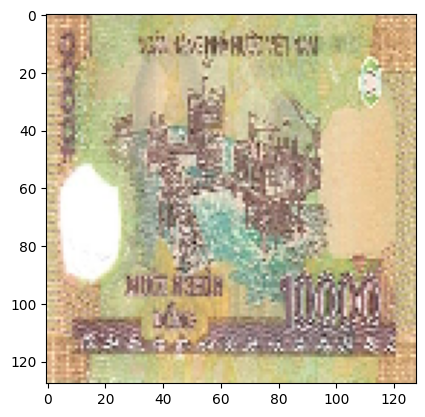

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Phán đoán của AI: Đây là tờ 10k
Độ tự tin (xác suất): 48.30%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Đường dẫn tới bức ảnh bạn muốn test
# LƯU Ý: Đổi đường dẫn này thành đường dẫn bức ảnh thực tế của bạn
test_image_path = "t.jpg"

# 2. Tải ảnh và ép về đúng kích thước đã train (128x128)
img = image.load_img(test_image_path, target_size=(128, 128))
plt.imshow(img) # Hiển thị bức ảnh ra màn hình
plt.show()

# 3. Tiền xử lý ảnh (chuyển thành ma trận số và chuẩn hóa)
img_array = image.img_to_array(img)
img_array = img_array / 255.0 # Chuẩn hóa màu sắc (đưa về 0-1) giống hệt Bước 2
img_array = np.expand_dims(img_array, axis=0) # Thêm 1 chiều vào ma trận (để máy hiểu đây là 1 bức ảnh độc lập)

# 4. Cho máy dự đoán
predictions = model_banknote.predict(img_array)
predicted_class_index = np.argmax(predictions) # Tìm vị trí có xác suất cao nhất

# 5. Dịch kết quả từ số sang tên mệnh giá (Tên thư mục)
# Lấy danh sách tên các loại tiền từ train_generator ở Bước 2
class_labels = {value: key for key, value in train_generator.class_indices.items()}
predicted_money = class_labels[predicted_class_index]

# In kết quả
print(f"Phán đoán của AI: Đây là tờ {predicted_money}")
print(f"Độ tự tin (xác suất): {np.max(predictions) * 100:.2f}%")

In [ ]:
from tensorflow.keras.models import load_model

# 1. Đường dẫn tới file model cũ của bạn (nhớ sửa tên file cho đúng bài bạn đang làm)
duong_dan_model_cu = "/content/drive/MyDrive/Banknote_Dataset/banknote_model.h5"

# 2. Tải mô hình lên
model = load_model(duong_dan_model_cu)
print("Đã gọi thành công bộ não cũ dậy! Sẵn sàng học tiếp!")

Đã gọi thành công bộ não cũ dậy! Sẵn sàng học tiếp!


In [ ]:
# 2. KHỞI TẠO LẠI OPTIMIZER (ĐÂY CHÍNH LÀ DÒNG FIX LỖI)
model.compile(
    optimizer='adam',
    # Lưu ý nhỏ: Nếu bài tiền của bạn chỉ phân loại 2 lớp (VD: Tiền Thật / Tiền Giả),
    # hãy đổi thành 'binary_crossentropy' nhé. Nếu từ 3 lớp trở lên thì giữ nguyên.
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Cho học bổ túc thêm 30 vòng
print("Bắt đầu khóa học bổ túc...")
history_extra = model.fit(
    train_generator,
    epochs=30
)

Bắt đầu khóa học bổ túc...
Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 7s/step - accuracy: 0.5828 - loss: 1.2194
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6424 - loss: 0.9074
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6755 - loss: 0.9020
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7219 - loss: 0.7719
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6887 - loss: 0.7401
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6887 - loss: 0.7694
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7152 - loss: 0.7335
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7616 - loss: 0.6518
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7219 - loss: 0.6869
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7417 - loss: 0.7146
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7020 - loss: 0.7339
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7351 - loss: 0.

In [8]:
# 4. Lưu lại thành phiên bản mới
model.save("/content/drive/MyDrive/banknote_model_V2.h5")
print("🎉 Đã cày xong và lưu thành công bản nâng cấp V2!")

🎉 Đã cày xong và lưu thành công bản nâng cấp V2!


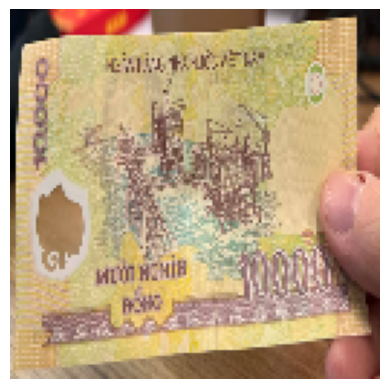

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Phán đoán của AI: Đây là tờ 10k
Độ tự tin (xác suất): 98.61%


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# ==========================================
# 1. TẢI MÔ HÌNH TỪ FILE H5 CŨ
# ==========================================
# Sửa lại tên file .h5 đúng với file bạn đang muốn test trong Drive
model_path = "/content/drive/MyDrive/banknote_model_V2.h5"
model_banknote = load_model(model_path)

# ==========================================
# 2. TIỀN XỬ LÝ ẢNH TEST (ĐÃ ÉP SANG RGB 3 KÊNH)
# ==========================================
test_image_path = "test.png"

# Load ảnh, chuyển về 128x128 và loại bỏ kênh trong suốt (.convert('RGB'))
img = image.load_img(test_image_path, target_size=(128, 128)).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.show()

# Biến đổi thành ma trận và chuẩn hóa màu sắc về khoảng [0-1]
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ==========================================
# 3. CHO MÁY DỰ ĐOÁN
# ==========================================
predictions = model_banknote.predict(img_array)
predicted_class_index = np.argmax(predictions)

# ==========================================
# 4. DỊCH KẾT QUẢ THEO THỨ TỰ ALPHABETICAL CỦA KERAS
# ==========================================
# Đây chính là mảng sắp xếp theo ký tự chuỗi mà bạn đã phát hiện ra:
class_labels = {
    0: '100k',
    1: '10k',
    2: '20k',
    3: '500k',
    4: '50k'
}

predicted_money = class_labels[predicted_class_index]

# In kết quả kiểm thử ngay trên Colab
print(f"Phán đoán của AI: Đây là tờ {predicted_money}")
print(f"Độ tự tin (xác suất): {np.max(predictions) * 100:.2f}%")